# Análise de Performance de Alunos

Este projeto tem como objetivo analisar uma base de dados de performance acadêmica de alunos,
avaliando como fatores como horas de estudo, sono, atividades extracurriculares e prática de
exercícios influenciam o desempenho final medido pelo **Performance Index**.

## Coleta de Dados

A base de dados utilizada neste projeto foi obtida na plataforma Kaggle.
Ela contém **10.000 registros** de alunos e **6 variáveis**, sendo elas:

- Hours Studied
- Previous Scores
- Extracurricular Activities
- Sleep Hours
- Sample Question Papers Practiced
- Performance Index

Os dados já se encontravam estruturados, não sendo necessário processo de scraping ou coleta externa.

## Visão Geral dos Dados

A base apresenta variáveis numéricas e uma variável categórica
(`Extracurricular Activities`), sem valores ausentes aparentes.

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("StudentPerformance.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [10]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


## Modelagem

Para este projeto, a modelagem consiste em analisar a relação entre as variáveis explicativas
e o **Performance Index**, utilizando estatísticas descritivas e correlação.

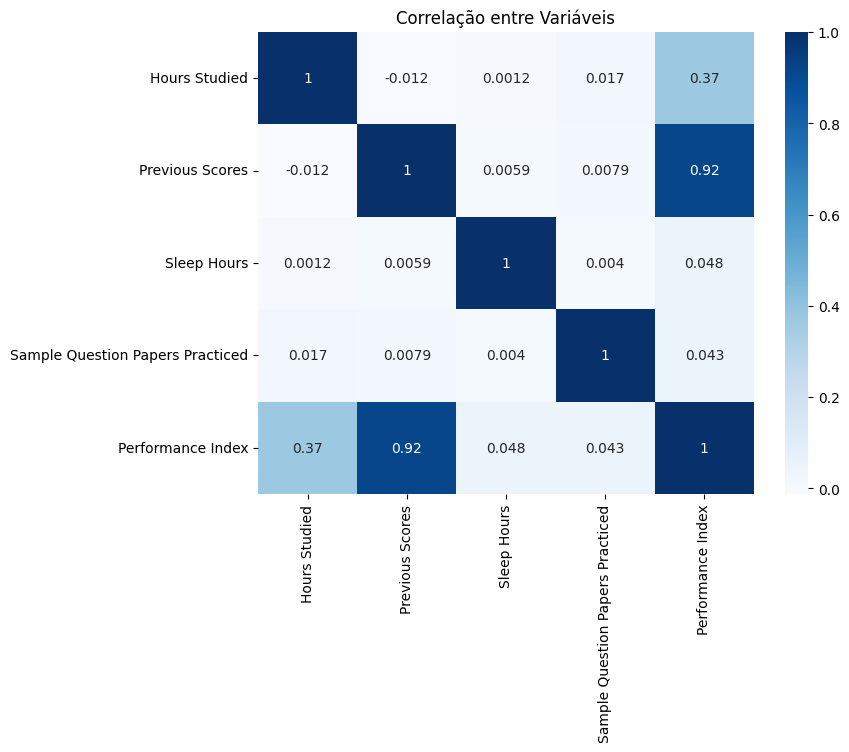

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="Blues")
plt.title("Correlação entre Variáveis")
plt.show()

Com base na matriz de correlação, observa-se que as variáveis **Previous Scores** e **Hours Studied**
apresentam as maiores correlações com a variável resposta **Performance Index**.

A variável **Previous Scores** demonstra uma correlação extremamente forte (≈ 0,92),
indicando que o desempenho anterior do aluno é o principal fator associado à performance atual.

Já **Hours Studied** apresenta uma correlação moderada positiva (≈ 0,37),
sugerindo que o aumento no tempo de estudo contribui para melhores resultados,
embora com impacto significativamente menor quando comparado às notas anteriores.

As demais variáveis — **Sleep Hours** e **Sample Question Papers Practiced** —
apresentam correlação fraca com o índice de performance, indicando que,
isoladamente, seu impacto linear direto é limitado.

No entanto, isso não descarta a possibilidade de efeitos indiretos ou não lineares,
que não são capturados pela correlação de Pearson.

sns.scatterplot(data=df, x="Hours Studied", y="Performance Index", alpha=0.4)
plt.title("Horas de Estudo vs Performance")
plt.show()

Observa-se uma relação positiva entre horas de estudo e índice de performance,
indicando que alunos que estudam mais tendem a apresentar melhor desempenho.

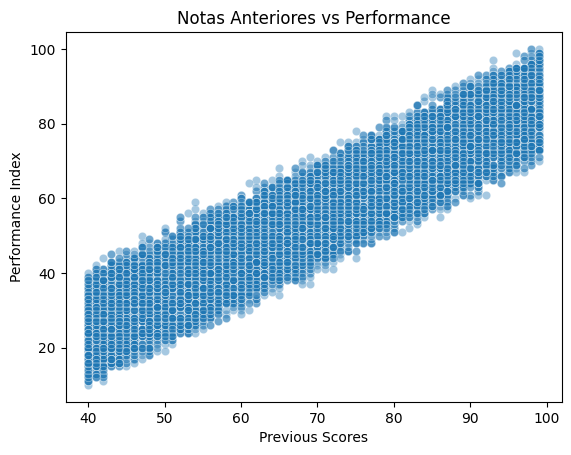

In [16]:
sns.scatterplot(data=df, x="Previous Scores", y="Performance Index", alpha=0.4)
plt.title("Notas Anteriores vs Performance")
plt.show()

E isso fica ainda mais claro quando observamos as notas anteriores de acordo com o indice de performance. É nitida a relação positiva entre as variáveis

## Conclusões

A análise indica que:

- **Horas de estudo** e **notas anteriores** são os principais fatores associados
  a um melhor desempenho acadêmico.
- **Prática com provas anteriores** demonstra impacto positivo consistente.

Esses resultados reforçam a importância de hábitos equilibrados de estudo,
prática contínua e qualidade de vida no desempenho acadêmico.

## Regressão Linear

Foi ajustado um modelo de regressão linear simples para avaliar o impacto conjunto
das variáveis **Hours Studied** e **Previous Scores** sobre o **Performance Index**.

In [18]:
X = df[["Hours Studied", "Previous Scores"]]
y = df["Performance Index"]

model = LinearRegression()
model.fit(X, y)

pd.DataFrame({
    "Variável": X.columns,
    "Coeficiente": model.coef_
})

,Variável,Coeficiente
0,Hours Studied,2.857637
1,Previous Scores,1.019123


## Interpretação da Regressão Linear

O modelo de regressão linear ajustado indicou que ambas as variáveis possuem
impacto positivo sobre o **Performance Index**.

Mantidas as demais variáveis constantes, um aumento de **1 hora de estudo**
está associado a um incremento médio de aproximadamente **2,86 pontos**
no índice de performance.

Já a variável **Previous Scores** apresentou coeficiente próximo de **1,02**,
indicando que o desempenho anterior funciona como um forte preditor basal,
contribuindo de forma consistente para o resultado final.

Embora **Previous Scores** apresente correlação mais elevada,
a regressão evidencia que **Hours Studied** possui maior impacto marginal,
reforçando a importância do esforço atual no desempenho acadêmico.

In [20]:
features = df[["Hours Studied", "Previous Scores", "Performance Index"]]
scaled = StandardScaler().fit_transform(features)

kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled)

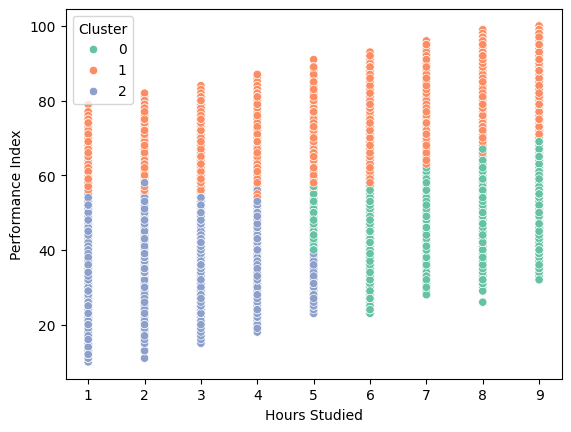

In [21]:
sns.scatterplot(
    data=df,
    x="Hours Studied",
    y="Performance Index",
    hue="Cluster",
    palette="Set2"
)
plt.show()

A clusterização permitiu identificar perfis distintos de alunos,
agrupando-os de acordo com padrões semelhantes de estudo e desempenho.

Técnicas de combinação de modelos (ensemble) como Random Forest ou Gradient Boosting
poderiam ser aplicadas para maximizar poder preditivo.

No entanto, considerando o objetivo exploratório do projeto
e a necessidade de interpretabilidade,
optou-se por modelos lineares simples.